In [165]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import h5py

In [ ]:
# Load the datasets - Training examples not arranged in column vectors
def load_dataset():
    current_dir = Path().resolve()
    dataset_dir = (current_dir / ".." / "Optional_Labs" / "W2A2" / "datasets").resolve()

    train_path = dataset_dir / "train_catvnoncat.h5"
    test_path = dataset_dir / "test_catvnoncat.h5"
    with h5py.File(train_path, "r") as f:
        X_train = f["train_set_x"][:]  # (209, 64, 64, 3)
        y_train = f["train_set_y"][:]  # (209,)
    with h5py.File(test_path, "r") as f:
        X_test = f["test_set_x"][:]  # (50, 64, 64, 3)
        y_test = f["test_set_y"][:]  # (50,)
        classes = f["list_classes"][:]  # [b'non-cat' b'cat']
    y_train, y_test = y_train.reshape(-1, 1), y_test.reshape(-1, 1)
    return X_train, y_train, X_test, y_test, classes

In [167]:
# Loading the data (cat/non-cat)
X_train, y_train, X_test, y_test, classes = load_dataset()
print(f"Shape of X_train : {X_train.shape}.  Shape of y_train : {y_train.shape}")
print(f"Shape of X_test : {X_test.shape}.  Shape of y_train : {y_test.shape}")
print(f"classes : {classes}")

Shape of X_train : (209, 64, 64, 3).  Shape of y_train : (209, 1)
Shape of X_test : (50, 64, 64, 3).  Shape of y_train : (50, 1)
classes : [b'non-cat' b'cat']


1
y = 1, it's a 'cat' picture.


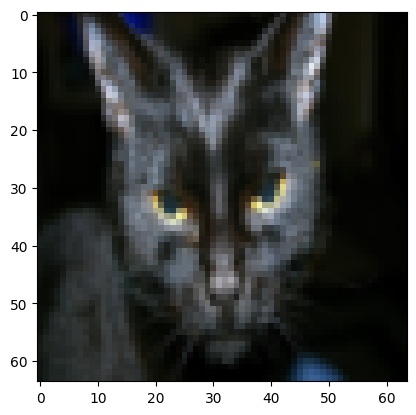

In [168]:
# Example of a picture
index = 25
plt.imshow(X_train[index])
y_val = y_train[index].squeeze()  # y_val would be [1] without squeeze()
print(y_val)
print(
    "y = " + str(y_val) + ", it's a '" + classes[y_val].decode("utf-8") + "' picture."
)

In [169]:
m_train = X_train.shape[0]
m_test = X_test.shape[0]
num_px = X_train.shape[1]
print("Number of training examples: m_train = " + str(m_train))
print("Number of testing examples: m_test = " + str(m_test))
print("Height/Width of each image: num_px = " + str(num_px))
print("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print("X_train shape: " + str(X_train.shape))
print("y_train shape: " + str(y_train.shape))
print("X_test shape: " + str(X_test.shape))
print("y_test shape: " + str(y_test.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
X_train shape: (209, 64, 64, 3)
y_train shape: (209, 1)
X_test shape: (50, 64, 64, 3)
y_test shape: (50, 1)


In [170]:
X_train = X_train.reshape(X_train.shape[0], -1)
print(X_train.shape)  # (209, 12288)

(209, 12288)


In [171]:
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_test.shape)  # (50, 12288)

(50, 12288)


In [172]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (209, 12288)
y_train shape: (209, 1)
X_test shape: (50, 12288)
y_test shape: (50, 1)


In [173]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [174]:
def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    out = np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))
    return out

In [176]:
print(sigmoid(np.array([0, 2])))
print(sigmoid(0))

[0.5        0.88079708]
0.5


In [177]:
def log_1pexp(z):
    z = np.asarray(z, dtype=np.float64)
    out = np.where(z >= 0, z + np.log1p(np.exp(-z)), np.log1p(np.exp(z)))
    return out

In [ ]:
def propagate(w, b, X, y):
    m = X.shape[0]
    z = X @ w + b  # w is (n, 1)
    A = sigmoid(z)
    cost = -y * z + log_1pexp(z)
    cost = np.sum(cost) / m
    e = A - y
    db = np.sum(e) / m
    dw = (X.T @ e) / m
    grads = {"dw": dw, "db": db}
    return grads, cost


# w = np.array([1.0, 2]).reshape(-1, 1)
# b = 1.5
# X = np.array([[1.0, 3.0], [-2.0, 0.5], [-1.0, -3.2]])
# Y = np.array([1, 1, 0]).reshape(-1, 1)
# grads, cost = propagate(w, b, X, Y)

# assert type(grads["dw"]) == np.ndarray
# assert grads["dw"].shape == (2, 1)
# assert type(grads["db"]) == np.float64


# print("dw = " + str(grads["dw"]))
# print("db = " + str(grads["db"]))
# print("cost = " + str(cost))

dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.12500404500439652
cost = 0.1590053770769241


In [191]:
w = np.array([1.0, 2]).reshape(-1, 1)
b = 1.5
X = np.array([[1.0, 3.0], [-2.0, 0.5], [-1.0, -3.2]])
Y = np.array([1, 1, 0]).reshape(-1, 1)
grads, cost = propagate(w, b, X, Y)

assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == (2, 1)
assert type(grads["db"]) == np.float64


print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))
print("cost = " + str(cost))

# propagate_test(propagate)

dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.12500404500439652
cost = 0.1590053770769241


In [192]:
import copy


def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - learning_rate * dw
        b = b - learning_rate * db
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print("Cost after iteration %i: %f" % (i, cost))
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    return params, grads, costs

In [193]:
params, grads, costs = optimize(
    w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False
)

print("w = " + str(params["w"]))
print("b = " + str(params["b"]))
print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))
print("Costs = " + str(costs))

# optimize_test(optimize)

w = [[0.80956046]
 [2.0508202 ]]
b = 1.5948713189708588
dw = [[ 0.17860505]
 [-0.04840656]]
db = -0.08888460336847771
Costs = [np.float64(0.1590053770769241)]


In [200]:
def predict(w, b, X, threshold=0.5):
    A = sigmoid(X @ w + b)
    return (A > threshold).astype(int)

In [201]:
w = np.array([[0.1124579], [0.23106775]])
b = -0.3
X = np.array([[1.0, 1.2], [-1.1, 2.0], [-3.2, 0.1]])
# X = np.array([[1.0, -1.1, -3.2], [1.2, 2.0, 0.1]])
print("predictions = " + str(predict(w, b, X)))

# predict_test(predict)

predictions = [[1]
 [1]
 [0]]


In [202]:
def model(
    X_train,
    Y_train,
    X_test,
    Y_test,
    num_iterations=2000,
    learning_rate=0.5,
    print_cost=False,
):
    w, b = np.zeros(X_train.shape[1]).reshape(-1, 1), 0.0
    params, grads, costs = optimize(
        w,
        b,
        X_train,
        Y_train,
        num_iterations=num_iterations,
        learning_rate=learning_rate,
        print_cost=print_cost,
    )
    w = params["w"]
    b = params["b"]
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    # Print train/test Errors
    if print_cost:
        print(
            "train accuracy: {} %".format(
                100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
            )
        )
        print(
            "test accuracy: {} %".format(
                100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
            )
        )

    d = {
        "costs": costs,
        "Y_prediction_test": Y_prediction_test,
        "Y_prediction_train": Y_prediction_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations,
    }

    return d

In [203]:
logistic_regression_model = model(
    X_train,
    y_train,
    X_test,
    y_test,
    num_iterations=2000,
    learning_rate=0.005,
    print_cost=True,
)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


y = 0, you predicted that it is a "cat" picture.


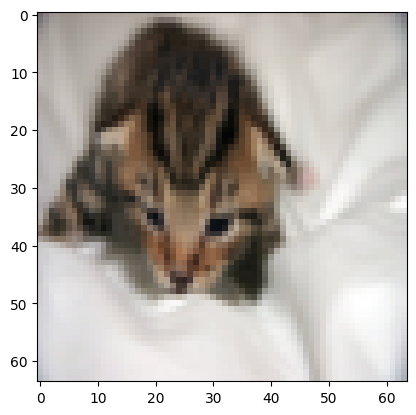

In [209]:
# Example of a picture that was wrongly classified.
index = 1
plt.imshow(X_test[index].reshape(64, 64, 3))
y_val = y_train[index].squeeze()
print(
    "y = "
    + str(y_val)
    + ', you predicted that it is a "'
    + classes[
        int(logistic_regression_model["Y_prediction_test"][index].squeeze())
    ].decode("utf-8")
    + '" picture.'
)

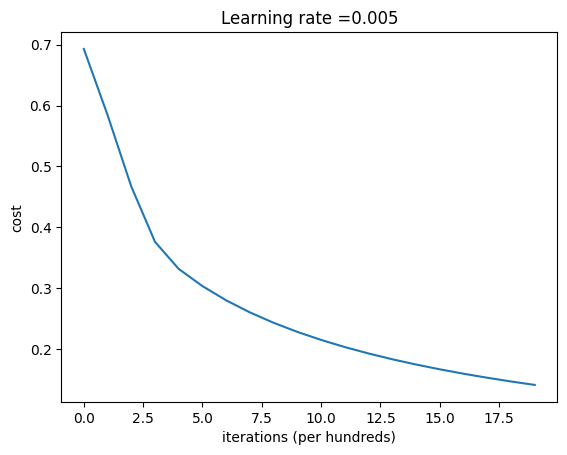

In [210]:
costs = np.squeeze(logistic_regression_model["costs"])
plt.plot(costs)
plt.ylabel("cost")
plt.xlabel("iterations (per hundreds)")
plt.title("Learning rate =" + str(logistic_regression_model["learning_rate"]))
plt.show()

Training a model with learning rate: 0.01

-------------------------------------------------------

Training a model with learning rate: 0.001

-------------------------------------------------------

Training a model with learning rate: 0.0001

-------------------------------------------------------



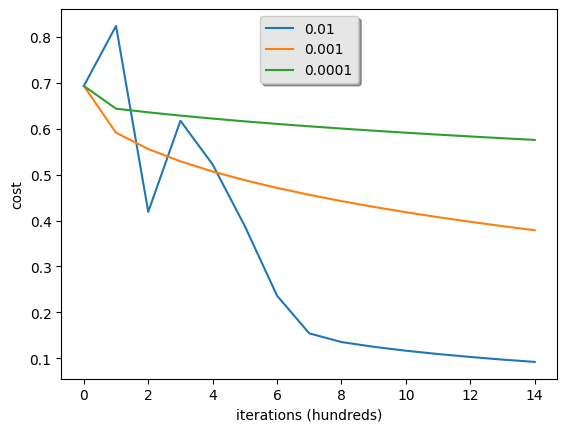

In [211]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print("Training a model with learning rate: " + str(lr))
    models[str(lr)] = model(
        X_train,
        y_train,
        X_test,
        y_test,
        num_iterations=1500,
        learning_rate=lr,
        print_cost=False,
    )
    print("\n" + "-------------------------------------------------------" + "\n")

for lr in learning_rates:
    plt.plot(
        np.squeeze(models[str(lr)]["costs"]),
        label=str(models[str(lr)]["learning_rate"]),
    )

plt.ylabel("cost")
plt.xlabel("iterations (hundreds)")
legend = plt.legend(loc="upper center", shadow=True)
frame = legend.get_frame()
frame.set_facecolor("0.90")
plt.show()

y = 1, your algorithm predicts a "cat" picture.


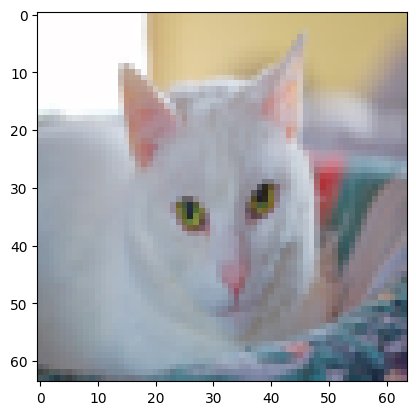

In [ ]:
current_dir = Path().resolve()
image = (
    current_dir / ".." / "Optional_Labs" / "W2A2" / "images" / "my_image2.jpg"
).resolve()
# my_image = "my_image.jpg"

# We preprocess the image to fit your algorithm.
fname = image
image = np.array(Image.open(fname).convert("RGB").resize((num_px, num_px)))
plt.imshow(image)
image = image / 255.0
image = image.reshape(1, -1)  # shape (1, 12288)
my_predicted_image = predict(
    logistic_regression_model["w"], logistic_regression_model["b"], image
)

print(
    "y = "
    + str(np.squeeze(my_predicted_image))
    + ', your algorithm predicts a "'
    + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8")
    + '" picture.'
)